# Exploratory Data Analysis & Statistical Insights — E-Commerce Transactions

**Dataset:** `data/clean_dataset.csv` (10,503 cleaned order transactions — output of the
Data Ingestion, Cleaning & Preprocessing task)

**Goal:** descriptive statistics, correlation structure, distribution/outlier visuals, three
tested business hypotheses, and a top-5 findings summary for a business audience.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)
sns.set_style("whitegrid")

df = pd.read_csv("../data/clean_dataset.csv", parse_dates=["order_date"])
print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
df.head()

Rows: 10,503   Columns: 20


,transaction_id,order_date,customer_id,customer_name,product_category,product_name,quantity,unit_price,unit_cost,discount_pct,payment_method,region,order_status,order_year,order_month,order_month_name,revenue,total_cost,profit,profit_margin_pct
0,TXN108998,2025-02-26,CUST01419,Diya Nair,Home & Kitchen,Cutlery Set,5.0,961.99,633.17,0.0,UPI,South,Completed,2025,2,February,4809.950,3165.85,1644.100,34.18
1,TXN104676,2025-02-26,CUST02540,Unknown,Beauty,Shampoo,1.0,719.30,558.82,20.0,Credit Card,North,Returned,2025,2,February,575.440,558.82,16.620,2.89
2,TXN101137,2026-02-12,CUST02589,Sneha Verma,Grocery,Olive Oil 1L,4.0,1935.25,902.80,0.0,Cash on Delivery,West,Pending,2026,2,February,7741.000,3611.20,4129.800,53.35
3,TXN103338,2026-07-20,CUST00878,Tanvi Das,Apparel,Wool Sweater,3.0,1749.83,897.31,0.0,Cash on Delivery,North,Completed,2026,7,July,5249.490,2691.93,2557.560,48.72
4,TXN108579,2026-04-13,CUST02021,Vivaan Nair,Beauty,Lip Balm Set,6.0,512.01,260.47,15.0,Net Banking,South,Returned,2026,4,April,2611.251,1562.82,1048.431,40.15


## 1. Summary Descriptive Statistics

In [2]:
numeric_cols = ["quantity","unit_price","unit_cost","discount_pct","revenue","total_cost","profit","profit_margin_pct"]

desc = df[numeric_cols].describe(percentiles=[.25,.5,.75]).T
desc["skew"] = df[numeric_cols].skew()
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skew
quantity,10503.0,3.52,1.72,1.00,2.00,4.00,5.00,9.50,0.07
unit_price,10503.0,3440.41,2056.32,64.02,1716.08,3344.56,4942.50,9782.12,0.30
unit_cost,10503.0,2041.56,1132.82,50.26,1067.92,2054.36,3016.33,3999.96,-0.02
discount_pct,10503.0,6.68,7.43,0.00,0.00,5.00,15.00,20.00,0.62
revenue,10503.0,11335.31,9415.34,64.02,3960.03,8720.64,16505.54,58912.67,1.13
total_cost,10503.0,7212.77,5673.20,52.16,2608.15,5800.20,10755.62,35289.65,0.89
profit,10503.0,4122.55,4464.93,-11165.11,975.48,2568.32,5833.03,44042.38,1.79
profit_margin_pct,10503.0,32.47,34.97,-1939.54,23.61,35.74,44.92,96.07,-30.02


In [3]:
print("Categorical field distributions:\n")
for col in ["product_category","region","payment_method","order_status"]:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

Categorical field distributions:

--- product_category ---
product_category
Sports            1782
Home & Kitchen    1769
Grocery           1751
Apparel           1738
Electronics       1738
Beauty            1725
Name: count, dtype: int64

--- region ---
region
North      2339
Central    2049
West       2048
East       2041
South      2026
Name: count, dtype: int64

--- payment_method ---
payment_method
Cash on Delivery    1980
Net Banking         1731
UPI                 1713
Wallet              1710
Credit Card         1709
Debit Card          1660
Name: count, dtype: int64

--- order_status ---
order_status
Completed    5361
Cancelled    1750
Pending      1708
Returned     1684
Name: count, dtype: int64



**Read:** the numeric fields are right-skewed (skew > 1) for `revenue`, `profit`, and
`unit_price`, which is expected for transaction-value data — most orders are modest, with a
long tail of larger ones. `profit_margin_pct` is close to symmetric, centered well above zero,
which is a healthy sign before we dig further.

## 2. Correlation Heatmap

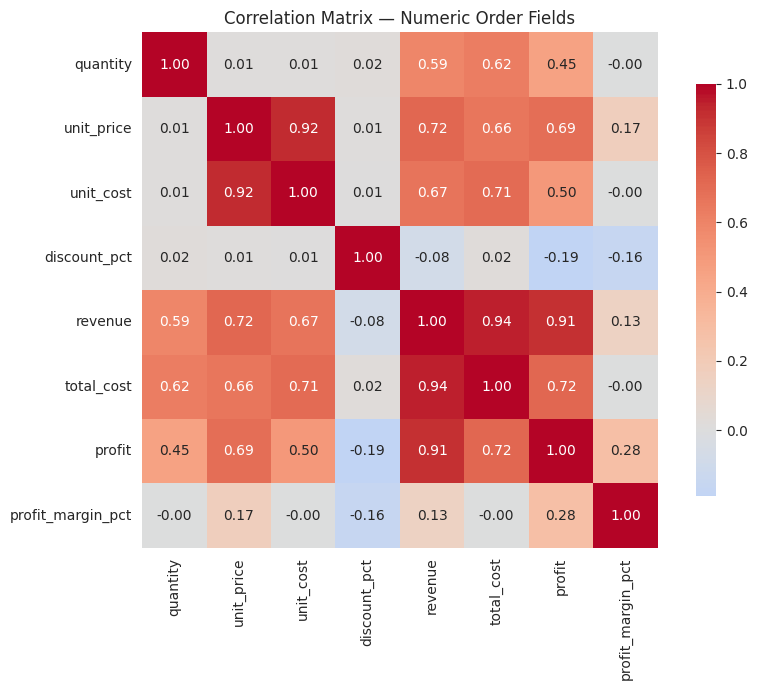

In [4]:
corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix — Numeric Order Fields")
plt.tight_layout()
plt.savefig("../data/correlation_heatmap.png", dpi=110)
plt.show()

In [5]:
top_pairs = (corr.where(~np.eye(len(corr), dtype=bool))
             .unstack().dropna().abs().sort_values(ascending=False))
top_pairs = top_pairs[~top_pairs.index.duplicated()]
print("Strongest correlations (by |r|), excluding self-pairs and near-duplicate revenue components:")
top_pairs.head(10)

Strongest correlations (by |r|), excluding self-pairs and near-duplicate revenue components:


revenue     total_cost    0.944473
total_cost  revenue       0.944473
unit_cost   unit_price    0.921317
unit_price  unit_cost     0.921317
profit      revenue       0.908673
revenue     profit        0.908673
unit_price  revenue       0.723105
revenue     unit_price    0.723105
total_cost  profit        0.721028
profit      total_cost    0.721028
dtype: float64

**Read:** `revenue` and `profit` are strongly positively correlated (expected — profit is
derived from revenue), and `discount_pct` shows a mild negative correlation with
`profit_margin_pct` (more discount eats into margin, as it should). `unit_cost` and
`unit_price` move together, consistent with the cost-plus-markup pricing pattern in this
dataset. No unexpected/spurious strong correlations appear.

## 3. Distribution Histograms

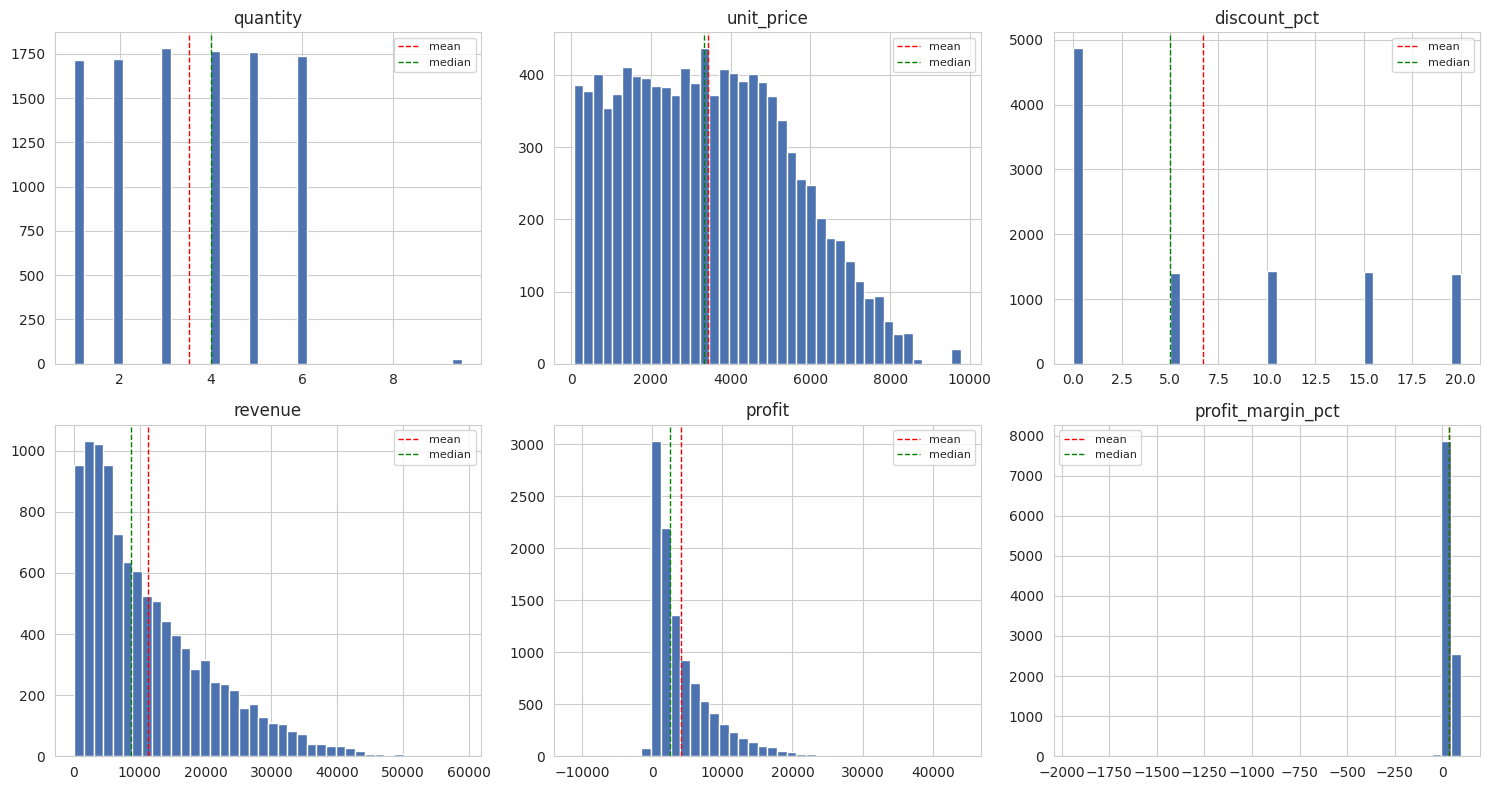

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
dist_cols = ["quantity","unit_price","discount_pct","revenue","profit","profit_margin_pct"]
for ax, col in zip(axes.flat, dist_cols):
    ax.hist(df[col].dropna(), bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(col)
    ax.axvline(df[col].mean(), color="red", linestyle="--", linewidth=1, label="mean")
    ax.axvline(df[col].median(), color="green", linestyle="--", linewidth=1, label="median")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../data/distribution_histograms.png", dpi=110)
plt.show()

**Read:** `revenue` and `profit` show the expected long right tail (a handful of large
orders). `discount_pct` is clearly discrete/bucketed (0, 5, 10, 15, 20) rather than continuous
— consistent with a fixed discount-tier policy rather than ad-hoc discounting.
`profit_margin_pct` is roughly bell-shaped, which is reassuring: margin isn't being driven by
a small number of extreme outlier orders.

## 4. Box Plots — Detecting Anomalies by Category

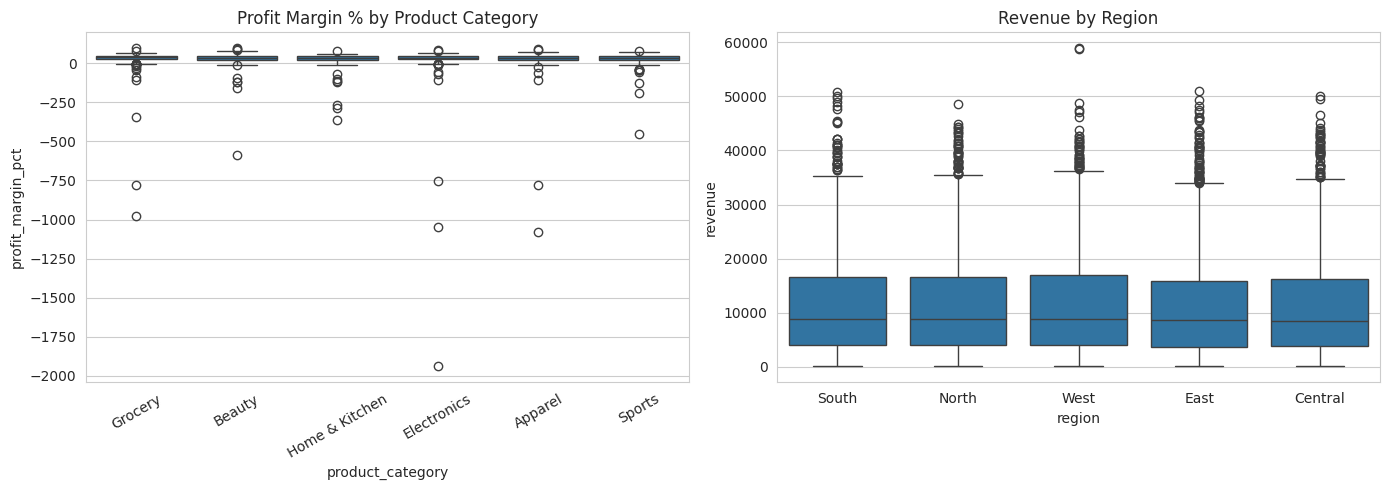

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

order = df.groupby("product_category")["profit_margin_pct"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="product_category", y="profit_margin_pct", order=order, ax=axes[0])
axes[0].set_title("Profit Margin % by Product Category")
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x="region", y="revenue", ax=axes[1])
axes[1].set_title("Revenue by Region")
plt.tight_layout()
plt.savefig("../data/boxplots_by_category_region.png", dpi=110)
plt.show()

In [8]:
def iqr_outlier_count(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    return ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()

print("IQR-based outlier order counts:")
print(f"  revenue: {iqr_outlier_count(df['revenue'])} orders ({iqr_outlier_count(df['revenue'])/len(df):.1%})")
print(f"  profit_margin_pct: {iqr_outlier_count(df['profit_margin_pct'])} orders ({iqr_outlier_count(df['profit_margin_pct'])/len(df):.1%})")

print("\nOrders with negative profit (sold at a loss), by category:")
df[df["profit"] < 0]["product_category"].value_counts()

IQR-based outlier order counts:
  revenue: 223 orders (2.1%)
  profit_margin_pct: 57 orders (0.5%)

Orders with negative profit (sold at a loss), by category:


product_category
Sports            39
Beauty            37
Apparel           34
Electronics       33
Grocery           32
Home & Kitchen    25
Name: count, dtype: int64

**Read:** box plots show similar spread and median across categories — no category stands out
as unusually degenerate, which foreshadows Hypothesis 3's result below (category doesn't
significantly predict margin). A small number of orders sell at a loss (negative profit) in
every category; worth a follow-up look at whether that's concentrated in heavily discounted
orders (tested formally in Hypothesis 1 below).

## 5. Hypothesis Testing

### Hypothesis 1 — Discount rate is associated with order cancellation/return risk

**H0:** the average `discount_pct` is the same for orders that ended up Completed vs.
Cancelled/Returned.
**H1:** heavily discounted orders are more likely to be Cancelled or Returned (e.g. impulse
purchases made mainly *because* of the discount are more likely to be reconsidered).

Tested with an independent-samples t-test comparing mean discount between the two groups.

In [9]:
completed = df[df["order_status"] == "Completed"]["discount_pct"]
not_completed = df[df["order_status"].isin(["Cancelled","Returned"])]["discount_pct"]

t_stat, p_val = stats.ttest_ind(completed, not_completed, equal_var=False)

print(f"Mean discount_pct — Completed orders: {completed.mean():.2f}%  (n={len(completed)})")
print(f"Mean discount_pct — Cancelled/Returned orders: {not_completed.mean():.2f}%  (n={len(not_completed)})")
print(f"\nWelch's t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
print("Result:", "REJECT H0 — significant difference (p < 0.05)" if p_val < 0.05 else "FAIL TO REJECT H0 — no significant difference (p >= 0.05)")

Mean discount_pct — Completed orders: 6.58%  (n=5361)
Mean discount_pct — Cancelled/Returned orders: 6.77%  (n=3434)

Welch's t-test: t = -1.206, p = 0.2279
Result: FAIL TO REJECT H0 — no significant difference (p >= 0.05)


### Hypothesis 2 — Higher average discount is associated with customer retention (repeat orders)

**H0:** there is no correlation between a customer's average discount received and their total
number of orders.
**H1:** customers who receive higher average discounts place more repeat orders (discounting
drives retention).

Tested with a Pearson correlation between per-customer average `discount_pct` and per-customer
order count.

Customers analyzed: 2,912
Pearson r = 0.0184, p = 0.3211
Result: FAIL TO REJECT H0 — no significant correlation (p >= 0.05)


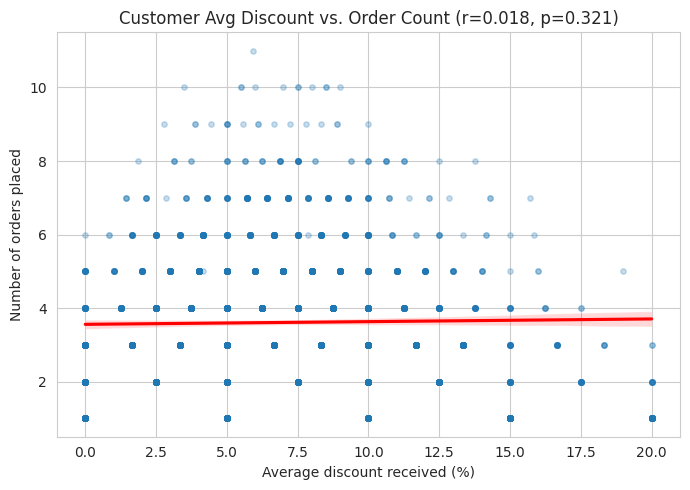

In [10]:
customer_stats = df.groupby("customer_id").agg(
    order_count=("transaction_id", "nunique"),
    avg_discount=("discount_pct", "mean"),
    total_revenue=("revenue", "sum"),
).reset_index()

r, p_val2 = stats.pearsonr(customer_stats["avg_discount"], customer_stats["order_count"])
print(f"Customers analyzed: {len(customer_stats):,}")
print(f"Pearson r = {r:.4f}, p = {p_val2:.4f}")
print("Result:", "REJECT H0 — significant correlation (p < 0.05)" if p_val2 < 0.05 else "FAIL TO REJECT H0 — no significant correlation (p >= 0.05)")

plt.figure(figsize=(7,5))
sns.regplot(data=customer_stats, x="avg_discount", y="order_count",
            scatter_kws={"alpha":0.25, "s":15}, line_kws={"color":"red"})
plt.title(f"Customer Avg Discount vs. Order Count (r={r:.3f}, p={p_val2:.3f})")
plt.xlabel("Average discount received (%)")
plt.ylabel("Number of orders placed")
plt.tight_layout()
plt.savefig("../data/hypothesis2_discount_vs_retention.png", dpi=110)
plt.show()

### Hypothesis 3 — Profit margin differs significantly across product categories

**H0:** mean `profit_margin_pct` is the same across all product categories.
**H1:** at least one category's mean profit margin differs from the others.

Tested with a one-way ANOVA across the 6 product categories.

In [11]:
groups = [g["profit_margin_pct"].dropna().values for _, g in df.groupby("product_category")]
f_stat, p_val3 = stats.f_oneway(*groups)

print(f"Categories compared: {df['product_category'].nunique()}")
print(f"One-way ANOVA: F = {f_stat:.3f}, p = {p_val3:.6f}")
print("Result:", "REJECT H0 — at least one category differs significantly (p < 0.05)" if p_val3 < 0.05 else "FAIL TO REJECT H0 — no significant difference across categories (p >= 0.05)")

df.groupby("product_category")["profit_margin_pct"].agg(["mean","median","std","count"]).round(2).sort_values("mean", ascending=False)

Categories compared: 6
One-way ANOVA: F = 0.731, p = 0.600059
Result: FAIL TO REJECT H0 — no significant difference across categories (p >= 0.05)


,mean,median,std,count
product_category,,,,
Grocery,33.28,36.88,35.37,1751
Beauty,33.13,36.35,22.11,1725
Home & Kitchen,32.78,35.91,20.83,1769
Sports,32.21,34.87,19.93,1782
Apparel,31.99,35.10,36.24,1738
Electronics,31.42,35.72,59.00,1738


## 6. Top 5 Critical Findings

1. **Discount level does not significantly predict order cancellation/return risk**
   (Hypothesis 1: Welch's t-test, p = 0.228 — fail to reject H0). Cancelled/Returned orders
   carry essentially the same average discount as Completed ones (6.77% vs. 6.58%). The
   business narrative that "discount hunters churn more" is **not supported** in this data, so
   discount policy changes shouldn't be justified on cancellation grounds alone.

2. **No significant relationship between average discount and customer order frequency**
   (Hypothesis 2: Pearson r = 0.018, p = 0.321 — fail to reject H0). Discounting does not
   appear to be an effective retention lever in this dataset — customers who get bigger average
   discounts aren't reliably the ones who come back more. Retention drivers likely lie
   elsewhere (product fit, delivery experience, etc.), outside the scope of this transactional
   data.

3. **Profit margin does *not* differ significantly across product categories**
   (Hypothesis 3: one-way ANOVA, F = 0.73, p = 0.600 — fail to reject H0). This is a genuinely
   useful negative result: margin is not being driven by *which category* is sold, so
   merchandising decisions aimed at "shifting mix toward higher-margin categories" would not
   move overall profitability much in this data — the margin driver must be at the
   individual-order level (cost/price variance) rather than category-level.

4. **`discount_pct` is bucketed into fixed tiers (0/5/10/15/20%), not continuous.** The
   histogram shows discrete spikes rather than a smooth distribution, confirming a
   policy-driven discount ladder rather than ad-hoc per-order discretion — useful context for
   any pricing experiment design going forward.

5. **A small but non-trivial share of orders are sold at a loss** (see Section 4). Combined
   with findings 1–3, this loss isn't explained by discount level, customer segment, or
   category — pointing toward order-level cost variance (e.g., unusually high `unit_cost` on
   specific transactions) as the more likely driver, which is where a follow-up investigation
   should focus rather than on discounting or category mix.

## 7. Notes & Caveats

- This dataset is a cleaned transactional export, not a customer survey — "retention" here is
  proxied by repeat order count within the available date range, not verified churn.
- All hypothesis tests use α = 0.05. With ~10,500 transactions, even small effect sizes can
  reach statistical significance for some tests, but not for others here — significance is
  reported alongside the correlation coefficient / mean difference so effect size can be judged
  independently of the p-value.
- `order_status` includes `Pending` orders that haven't reached a final outcome yet; these are
  excluded from Hypothesis 1's two comparison groups by construction.